# Density smoothing preview

Use this notebook to preview the support-masked Gaussian smoothing without rerunning `download_prob_maps.ipynb`. It loads the existing `prob_maps_2025-03-21.npz`, applies the current smoothing helper from `velocity_density_pipeline.py` to copies of the loaded density maps, and plots before/after comparisons.

Important: if the current `.npz` was generated with the earlier original-equivalent support maps, this notebook rescales those support maps back to approximate raw cloned-point support using the population `clone_factor`. That is good enough for previewing the smoothing behavior, but the final production maps should still be regenerated once the parameters look right.

In [1]:
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from scipy.ndimage import gaussian_filter

cwd = Path.cwd().resolve()
candidate_module_dirs = [cwd, cwd / 'neomod', cwd.parent / 'neomod']
for module_dir in candidate_module_dirs:
    if (module_dir / 'src' / 'velocity_density_pipeline.py').exists():
        sys.path.insert(0, str(module_dir / 'src'))
        NEOMOD_DIR = module_dir
        break
else:
    raise FileNotFoundError('Could not find velocity_density_pipeline.py from this notebook cwd.')

import velocity_density_pipeline as vdp

PROB_MAPS_PATH = NEOMOD_DIR / 'prob_maps_2025-03-21.npz'
CLONE_FACTORS = {
    'MBA': 10,
    'NEO': 300,
    'TNO': 100,
    'Trojans': 100,
}

prob_mapset = vdp.ProbMapSet.from_npz(PROB_MAPS_PATH)
X0, Y0 = prob_mapset.get_xy_meshgrid()

print('Loaded:', PROB_MAPS_PATH)
print('Bins:', [mb['label'] for mb in prob_mapset.mag_bins])
print('Pops:', prob_mapset.population_names)
print('Saved smoothing metadata:', prob_mapset.smoothing)

Loaded: /Users/devanshisingh/Downloads/research/NEO_probability/neomod/prob_maps_2025-03-21.npz
Bins: ['14_16', '16_18', '18_20', 'mag20', 'mag21', 'mag22', 'mag23', 'mag24+']
Pops: ['MBA', 'NEO', 'TNO', 'Trojans']
Saved smoothing metadata: {'enabled': True, 'support_threshold': 3.0, 'sigma_pixels': 1.5, 'truncate_sigma': 5.0}


In [2]:
# These defaults match velocity_density_pipeline.py's production VDP smoothing.
# Tune only if deliberately testing an alternate setting.
MAG_BIN = 'mag21'
POPS = ['MBA', 'NEO', 'TNO', 'Trojans']

SUPPORT_THRESHOLD = 10.0
SIGMA_PIXELS = 2.0
TRUNCATE_SIGMA = 5.0

# 'support' calls vdp.smooth_density_map_by_support, the same path used when
# production VDP probability maps are built. The footprint modes below are
# visual experiments only and should not be used for matching production VDP.
SMOOTH_MODE = 'support'
FOOTPRINT_DYNAMIC_RANGE_DEX = 5.0

# Set to True for the current May 6 test .npz if its support maps were saved
# as original-equivalent counts. Future regenerated .npz files should use False.
RESCALE_SUPPORT_BY_CLONE_FACTOR = True

In [3]:
def density_log_map(density):
    log_map = np.log10(np.maximum(density, 1e-30))
    vmax = float(np.nanmax(log_map))
    vmin = vmax - 5.0
    return log_map, vmin, vmax


def preview_support_map(label, pop):
    support = prob_mapset.results[label]['support_count_maps'][pop].copy()
    if RESCALE_SUPPORT_BY_CLONE_FACTOR:
        support = support * CLONE_FACTORS[pop]
    return support


def density_footprint(density):
    finite = np.isfinite(density) & (density > 0)
    if not np.any(finite):
        return finite
    floor = np.nanmax(density[finite]) * 10.0 ** (-FOOTPRINT_DYNAMIC_RANGE_DEX)
    return finite & (density >= floor)


def smooth_density_over_footprint(density, log_space=False):
    footprint = density_footprint(density)
    if not np.any(footprint):
        return density.copy()
    weights = footprint.astype(float)
    if log_space:
        source = np.log10(np.maximum(density, 1e-30))
    else:
        source = density
    numerator = gaussian_filter(
        np.where(footprint, source, 0.0),
        sigma=SIGMA_PIXELS,
        truncate=TRUNCATE_SIGMA,
        mode='constant',
        cval=0.0,
    )
    denominator = gaussian_filter(
        weights,
        sigma=SIGMA_PIXELS,
        truncate=TRUNCATE_SIGMA,
        mode='constant',
        cval=0.0,
    )
    smoothed = density.copy()
    good = footprint & (denominator > 0)
    averaged = numerator[good] / denominator[good]
    if log_space:
        smoothed[good] = 10.0 ** averaged
    else:
        smoothed[good] = averaged
    return smoothed


def preview_smoothed_density(label, pop):
    density = prob_mapset.results[label]['density_maps_downweighted_raw'][pop]
    if SMOOTH_MODE == 'footprint_linear':
        return smooth_density_over_footprint(density, log_space=False)
    if SMOOTH_MODE == 'footprint_log':
        return smooth_density_over_footprint(density, log_space=True)
    if SMOOTH_MODE != 'support':
        raise ValueError("SMOOTH_MODE must be 'support', 'footprint_linear', or 'footprint_log'.")
    support = preview_support_map(label, pop)
    return vdp.smooth_density_map_by_support(
        density,
        support,
        support_threshold=SUPPORT_THRESHOLD,
        sigma_pixels=SIGMA_PIXELS,
        truncate_sigma=TRUNCATE_SIGMA,
    )


def smoothing_stats(label, pop):
    density = prob_mapset.results[label]['density_maps_downweighted_raw'][pop]
    support = preview_support_map(label, pop)
    smoothed = preview_smoothed_density(label, pop)
    footprint = density_footprint(density)
    local_support = gaussian_filter(
        support,
        sigma=SIGMA_PIXELS,
        truncate=TRUNCATE_SIGMA,
        mode='constant',
        cval=0.0,
    )
    changed = np.isfinite(density) & (np.abs(smoothed - density) > 0)
    if SMOOTH_MODE in ('footprint_linear', 'footprint_log'):
        eligible = footprint
    else:
        eligible = np.isfinite(local_support) & (local_support >= SUPPORT_THRESHOLD)
    return {
        'mode': SMOOTH_MODE,
        'support_max': float(np.nanmax(support)),
        'local_support_max': float(np.nanmax(local_support)),
        'footprint_pixels': int(np.sum(footprint)),
        'eligible_pixels': int(np.sum(eligible)),
        'changed_pixels': int(np.sum(changed)),
        'median_abs_delta': float(np.nanmedian(np.abs(smoothed[eligible] - density[eligible]))) if np.any(eligible) else 0.0,
    }


for pop in POPS:
    print(pop, smoothing_stats(MAG_BIN, pop))

MBA {'mode': 'support', 'support_max': 79350.0, 'local_support_max': 41876.645771907926, 'footprint_pixels': 3411, 'eligible_pixels': 1798, 'changed_pixels': 1798, 'median_abs_delta': 3535.3937221150036}
NEO {'mode': 'support', 'support_max': 24300.0, 'local_support_max': 14715.190026102006, 'footprint_pixels': 25921, 'eligible_pixels': 13973, 'changed_pixels': 13973, 'median_abs_delta': 1.2357382473487757}
TNO {'mode': 'support', 'support_max': 1735900.0, 'local_support_max': 74713.04842907103, 'footprint_pixels': 91, 'eligible_pixels': 225, 'changed_pixels': 225, 'median_abs_delta': 517627.9248767941}
Trojans {'mode': 'support', 'support_max': 929800.0, 'local_support_max': 248213.17317391542, 'footprint_pixels': 371, 'eligible_pixels': 480, 'changed_pixels': 480, 'median_abs_delta': 2786.370633612013}


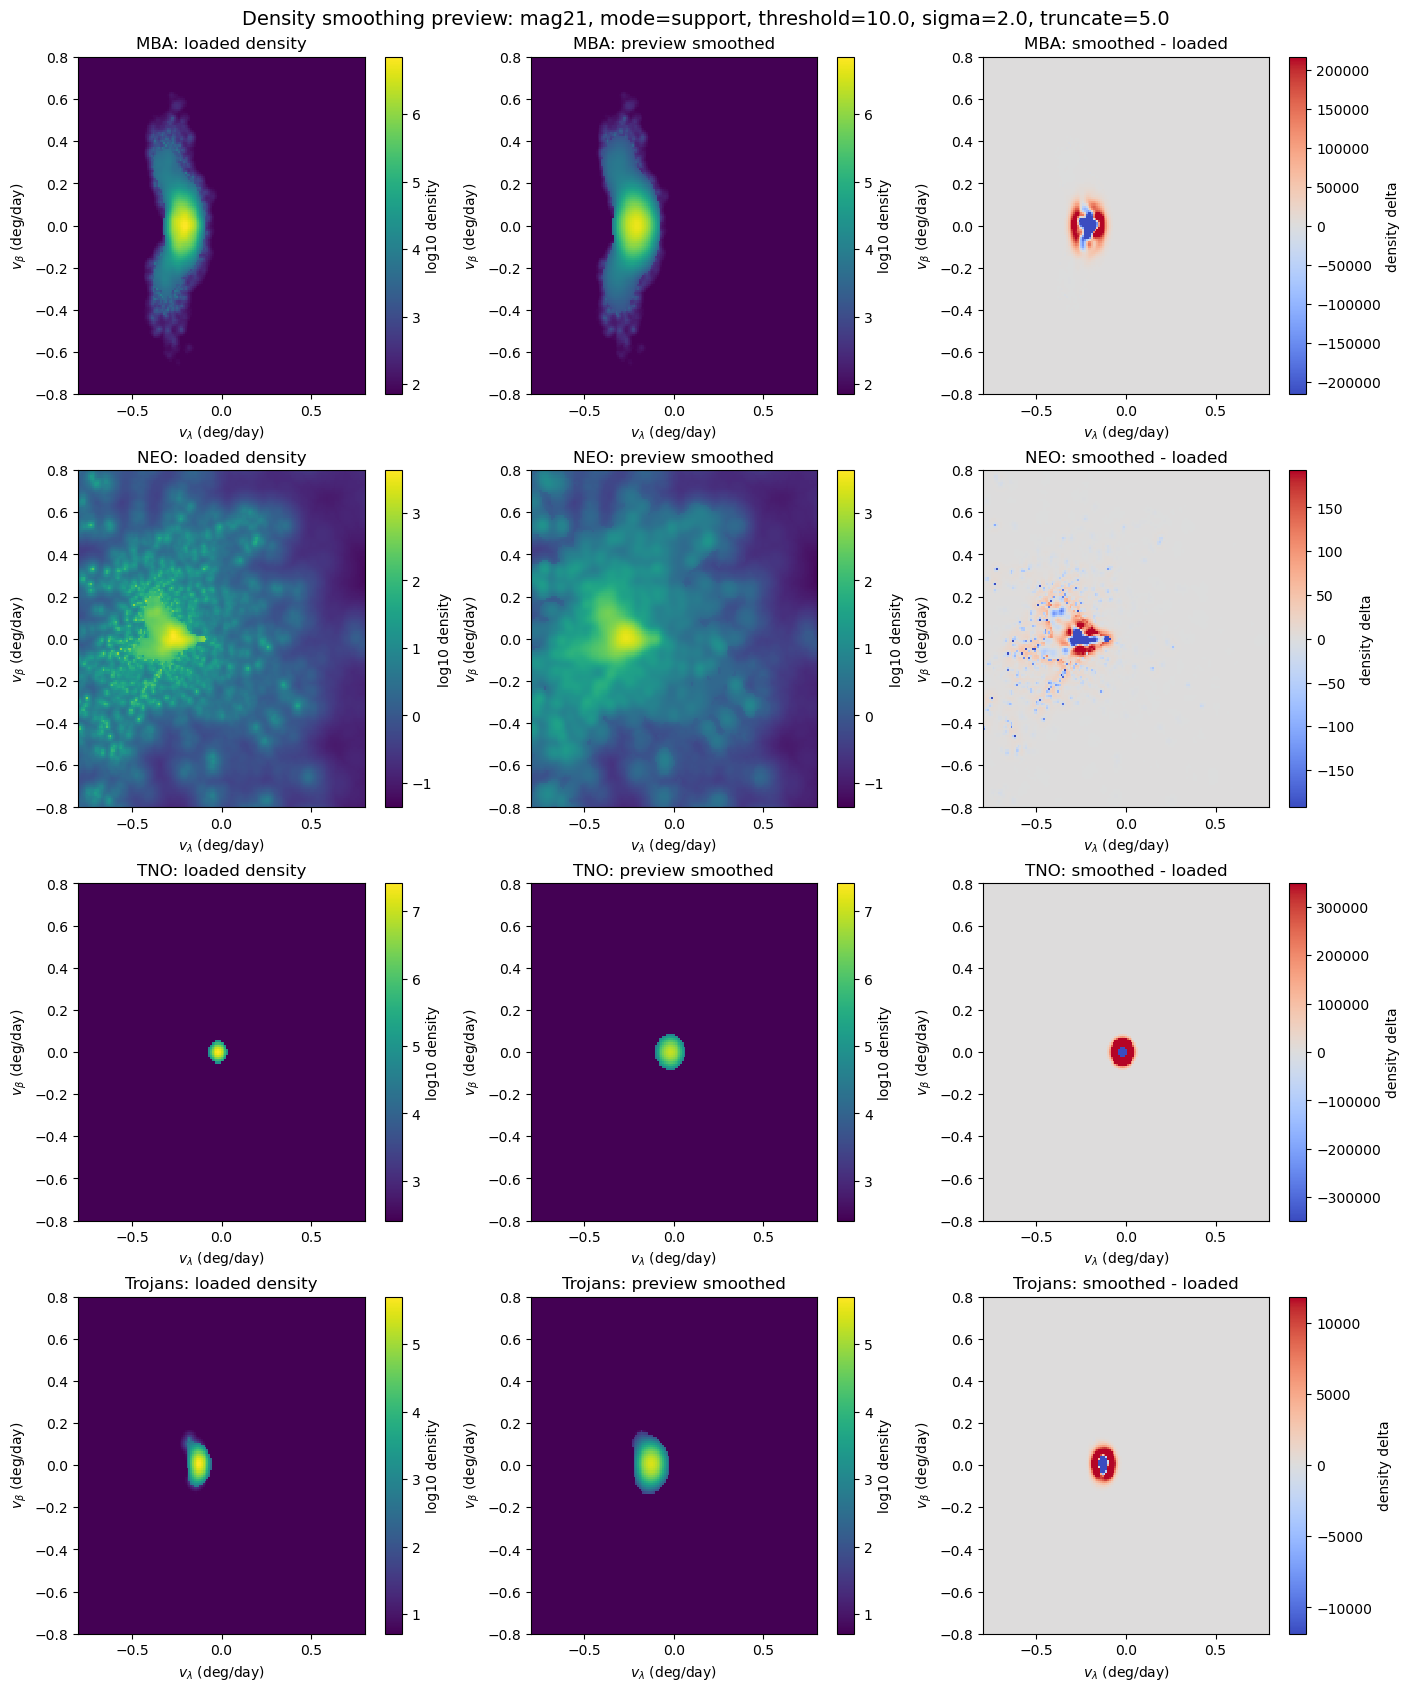

In [4]:
def plot_density_before_after(label=MAG_BIN, pops=POPS):
    fig, axes = plt.subplots(len(pops), 3, figsize=(14, 4.2 * len(pops)), constrained_layout=True)
    axes = np.atleast_2d(axes)

    for row, pop in enumerate(pops):
        density = prob_mapset.results[label]['density_maps_downweighted_raw'][pop]
        smoothed = preview_smoothed_density(label, pop)
        delta = smoothed - density

        data0, vmin, vmax = density_log_map(density)
        data1, _, _ = density_log_map(smoothed)

        im0 = axes[row, 0].pcolormesh(X0, Y0, data0, shading='auto', cmap='viridis', vmin=vmin, vmax=vmax)
        axes[row, 0].set_title(f'{pop}: loaded density')
        fig.colorbar(im0, ax=axes[row, 0], label='log10 density')

        im1 = axes[row, 1].pcolormesh(X0, Y0, data1, shading='auto', cmap='viridis', vmin=vmin, vmax=vmax)
        axes[row, 1].set_title(f'{pop}: preview smoothed')
        fig.colorbar(im1, ax=axes[row, 1], label='log10 density')

        lim = np.nanpercentile(np.abs(delta), 99.5)
        if not np.isfinite(lim) or lim == 0:
            lim = 1.0
        im2 = axes[row, 2].pcolormesh(X0, Y0, delta, shading='auto', cmap='coolwarm', vmin=-lim, vmax=lim)
        axes[row, 2].set_title(f'{pop}: smoothed - loaded')
        fig.colorbar(im2, ax=axes[row, 2], label='density delta')

        for ax in axes[row]:
            ax.set_xlim(-0.8, 0.8)
            ax.set_ylim(-0.8, 0.8)
            ax.set_xlabel(r'$v_\lambda$ (deg/day)')
            ax.set_ylabel(r'$v_\beta$ (deg/day)')

    fig.suptitle(
        f'Density smoothing preview: {label}, mode={SMOOTH_MODE}, threshold={SUPPORT_THRESHOLD}, '
        f'sigma={SIGMA_PIXELS}, truncate={TRUNCATE_SIGMA}',
        fontsize=14,
    )
    plt.show()


plot_density_before_after()

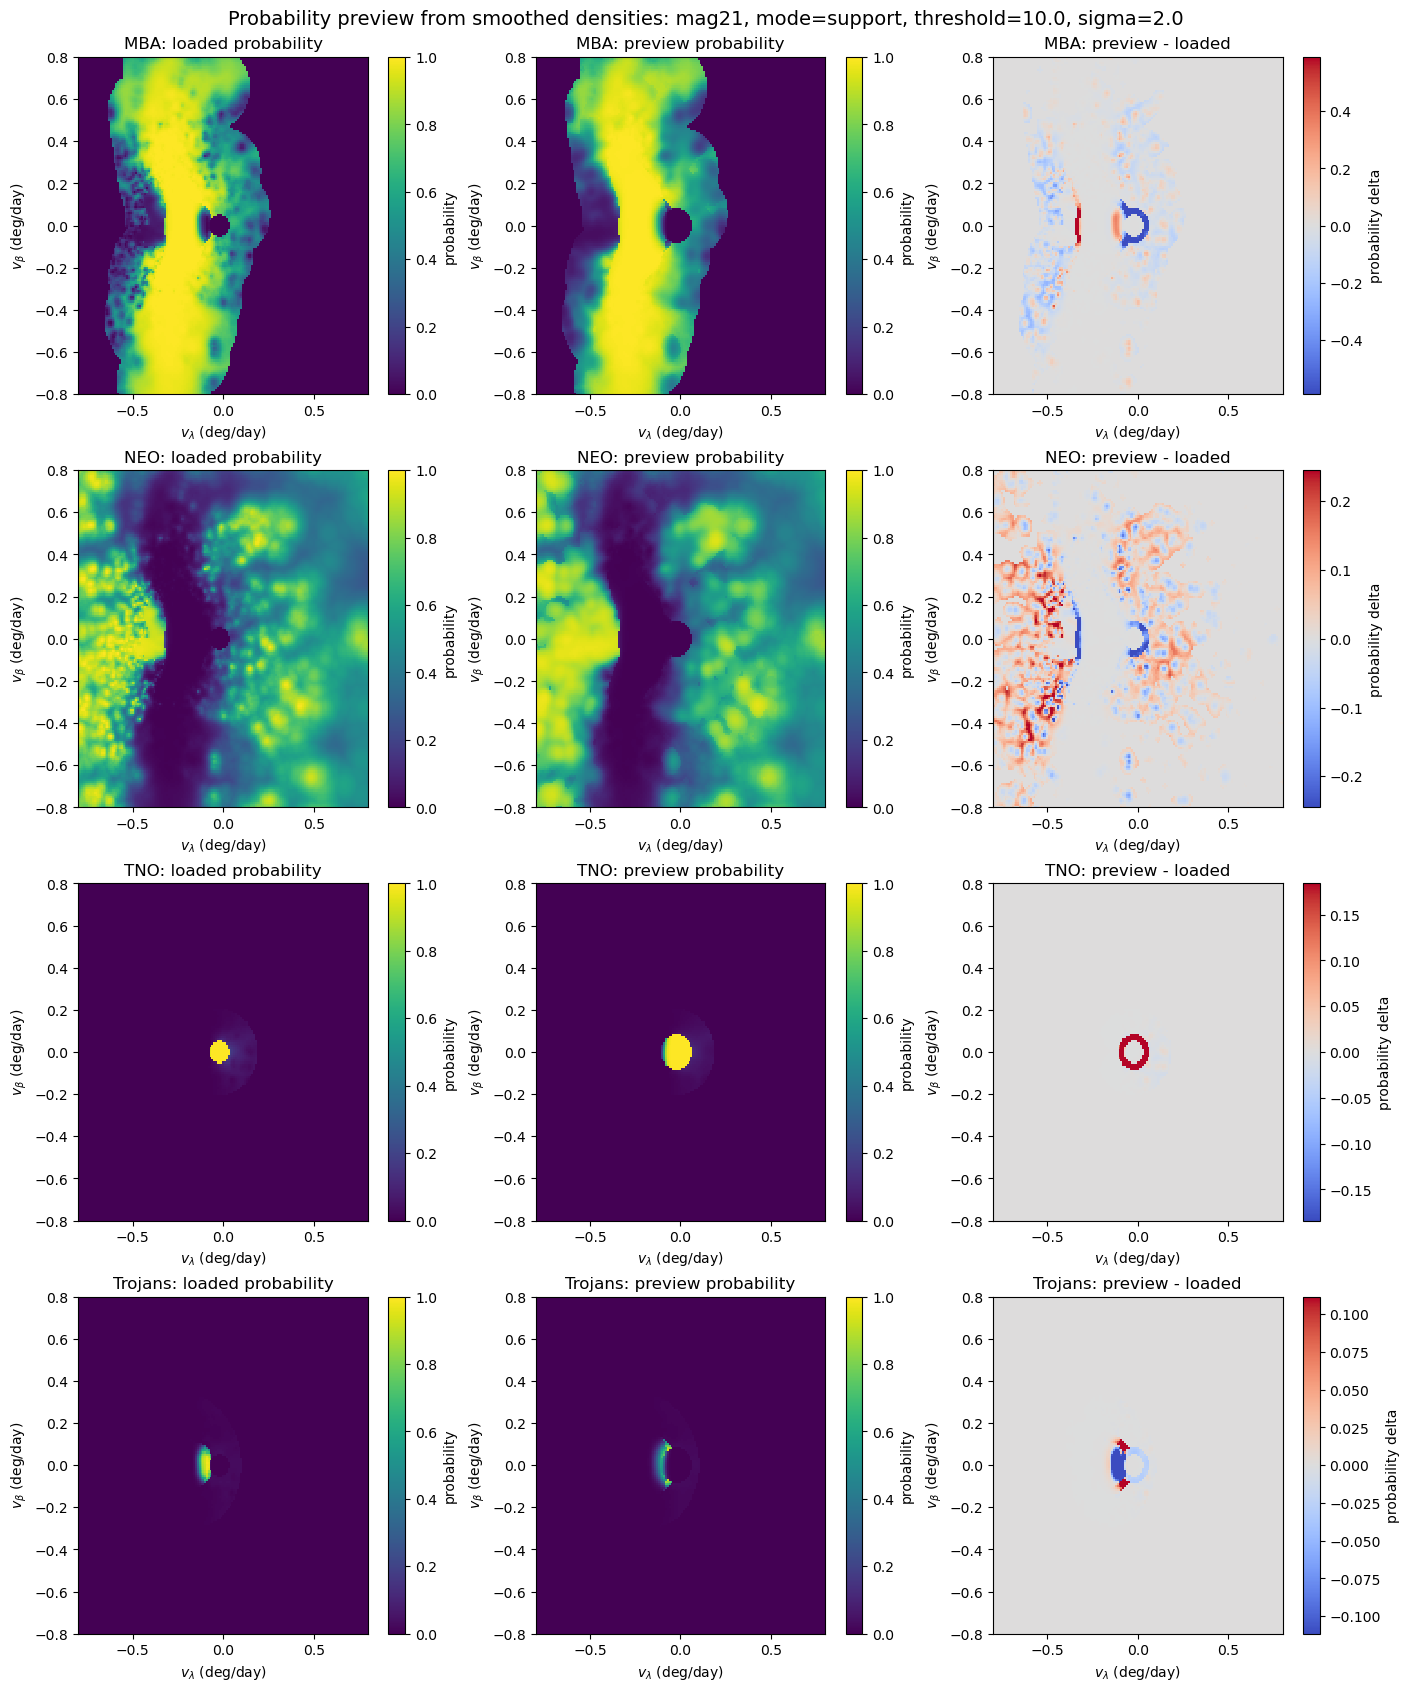

In [5]:
def make_preview_probability_maps(label):
    smoothed_density = {
        pop: preview_smoothed_density(label, pop)
        for pop in prob_mapset.population_names
    }
    total = sum(smoothed_density.values())
    out = {}
    for pop in prob_mapset.population_names:
        frac = np.zeros_like(total, dtype=float)
        good = total > 0
        frac[good] = smoothed_density[pop][good] / total[good]
        too_far = prob_mapset.results[label]['nearest_dist_maps'][pop] > prob_mapset.mask_radius_deg_per_day
        frac[too_far] = 0.0
        out[pop] = frac
    return out


def plot_probability_before_after(label=MAG_BIN, pops=POPS):
    preview_probs = make_preview_probability_maps(label)
    fig, axes = plt.subplots(len(pops), 3, figsize=(14, 4.2 * len(pops)), constrained_layout=True)
    axes = np.atleast_2d(axes)

    for row, pop in enumerate(pops):
        before = prob_mapset.get_probability_map(label, pop)
        after = preview_probs[pop]
        delta = after - before

        im0 = axes[row, 0].pcolormesh(X0, Y0, before, shading='auto', cmap='viridis', vmin=0, vmax=1)
        axes[row, 0].set_title(f'{pop}: loaded probability')
        fig.colorbar(im0, ax=axes[row, 0], label='probability')

        im1 = axes[row, 1].pcolormesh(X0, Y0, after, shading='auto', cmap='viridis', vmin=0, vmax=1)
        axes[row, 1].set_title(f'{pop}: preview probability')
        fig.colorbar(im1, ax=axes[row, 1], label='probability')

        lim = np.nanpercentile(np.abs(delta), 99.5)
        if not np.isfinite(lim) or lim == 0:
            lim = 0.1
        im2 = axes[row, 2].pcolormesh(X0, Y0, delta, shading='auto', cmap='coolwarm', vmin=-lim, vmax=lim)
        axes[row, 2].set_title(f'{pop}: preview - loaded')
        fig.colorbar(im2, ax=axes[row, 2], label='probability delta')

        for ax in axes[row]:
            ax.set_xlim(-0.8, 0.8)
            ax.set_ylim(-0.8, 0.8)
            ax.set_xlabel(r'$v_\lambda$ (deg/day)')
            ax.set_ylabel(r'$v_\beta$ (deg/day)')

    fig.suptitle(
        f'Probability preview from smoothed densities: {label}, mode={SMOOTH_MODE}, '
        f'threshold={SUPPORT_THRESHOLD}, sigma={SIGMA_PIXELS}',
        fontsize=14,
    )
    plt.show()


plot_probability_before_after()

## Quick parameter sweep

Use this cell to see how the NEO panel changes for several `sigma` values at the same support threshold. This is usually the fastest way to choose whether `sigma=1`, `1.5`, or `2` is better.

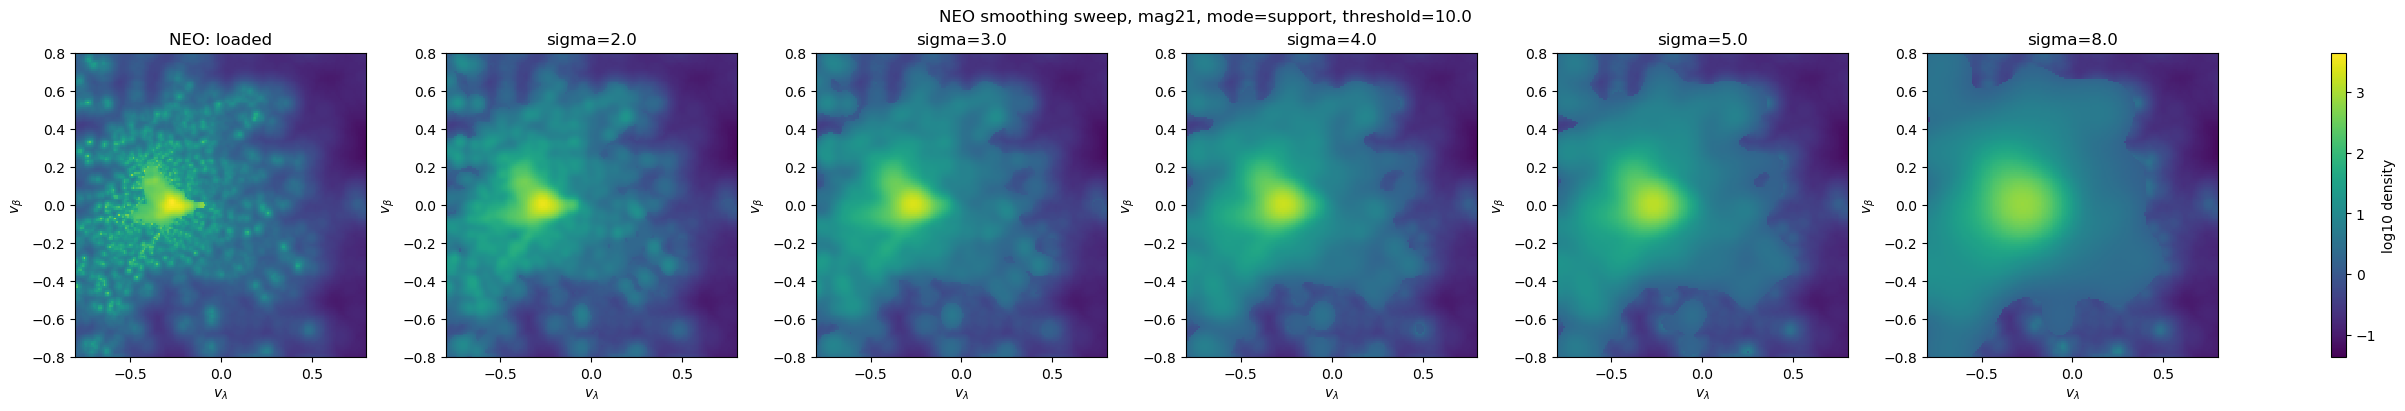

In [6]:
SWEEP_POP = 'NEO'
SWEEP_SIGMAS = [2.0, 3.0, 4.0, 5.0, 8.0]

density = prob_mapset.results[MAG_BIN]['density_maps_downweighted_raw'][SWEEP_POP]
support = preview_support_map(MAG_BIN, SWEEP_POP)
base_log, vmin, vmax = density_log_map(density)

fig, axes = plt.subplots(1, 1 + len(SWEEP_SIGMAS), figsize=(4 * (1 + len(SWEEP_SIGMAS)), 4), constrained_layout=True)

im = axes[0].pcolormesh(X0, Y0, base_log, shading='auto', cmap='viridis', vmin=vmin, vmax=vmax)
axes[0].set_title(f'{SWEEP_POP}: loaded')

old_sigma = SIGMA_PIXELS
for ax, sigma in zip(axes[1:], SWEEP_SIGMAS):
    SIGMA_PIXELS = sigma
    if SMOOTH_MODE == 'footprint_linear':
        smoothed = smooth_density_over_footprint(density, log_space=False)
    elif SMOOTH_MODE == 'footprint_log':
        smoothed = smooth_density_over_footprint(density, log_space=True)
    else:
        smoothed = vdp.smooth_density_map_by_support(
            density,
            support,
            support_threshold=SUPPORT_THRESHOLD,
            sigma_pixels=sigma,
            truncate_sigma=TRUNCATE_SIGMA,
        )
    log_map, _, _ = density_log_map(smoothed)
    ax.pcolormesh(X0, Y0, log_map, shading='auto', cmap='viridis', vmin=vmin, vmax=vmax)
    ax.set_title(f'sigma={sigma}')
SIGMA_PIXELS = old_sigma

for ax in axes:
    ax.set_xlim(-0.8, 0.8)
    ax.set_ylim(-0.8, 0.8)
    ax.set_xlabel(r'$v_\lambda$')
    ax.set_ylabel(r'$v_\beta$')

fig.colorbar(im, ax=axes, label='log10 density')
fig.suptitle(f'{SWEEP_POP} smoothing sweep, {MAG_BIN}, mode={SMOOTH_MODE}, threshold={SUPPORT_THRESHOLD}')
plt.show()